<a href="https://colab.research.google.com/github/lovnishverma/Python-Getting-Started/blob/main/decision_trees_random_forest_(practical).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌳 Decision Trees & Random Forests
## A Practical Guide Using Real-World Medical Data

> **Dataset**: Breast Cancer Wisconsin (Diagnostic) — 569 patient records, 30 clinical features  
> **Goal**: Learn tree-based models from scratch, understand their internals, and master Random Forests

---

### 📚 What You'll Learn
1. How Decision Trees split data (Gini impurity vs Entropy)
2. Visualizing and interpreting a trained tree
3. The overfitting problem and how to prune trees
4. Why Random Forests fix overfitting (Bagging + Feature Randomness)
5. Feature Importance and model interpretation
6. Hyperparameter tuning with GridSearchCV
7. Comparing Decision Tree vs Random Forest on the same dataset

---
## 🏥 Section 1: The Dataset — Breast Cancer Wisconsin

This is a **real clinical dataset** from the UCI Machine Learning Repository.

- **569 samples** of tumor biopsies from patients
- **30 features** computed from digitized images of fine needle aspirates (FNA)
- Features describe characteristics of cell nuclei: radius, texture, perimeter, area, smoothness, etc.
- **Target**: Malignant (1) or Benign (0)

> 🔍 **Clinical context**: Early and accurate cancer detection saves lives. A model that confuses malignant for benign is far more dangerous than the reverse — we'll keep this in mind when evaluating performance.

In [ ]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, accuracy_score
)
from sklearn.preprocessing import label_binarize

# Aesthetic config
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#3a3d4d',
    'axes.labelcolor':  '#e2e8f0',
    'xtick.color':      '#94a3b8',
    'ytick.color':      '#94a3b8',
    'text.color':       '#e2e8f0',
    'grid.color':       '#2d3044',
    'grid.linewidth':   0.6,
    'axes.grid':        True,
    'font.family':      'monospace',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})

PALETTE = {'Benign': '#38bdf8', 'Malignant': '#f87171'}
C_BEN   = '#38bdf8'
C_MAL   = '#f87171'
C_ACC   = '#34d399'

print('All libraries imported successfully!')

All libraries imported successfully!


In [ ]:
# Load dataset
cancer = load_breast_cancer()

df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['diagnosis'] = cancer.target          # 0 = Malignant, 1 = Benign
df['diagnosis_label'] = df['diagnosis'].map({0: 'Malignant', 1: 'Benign'})

print(f'Dataset shape  : {df.shape}')
print(f'Features       : {cancer.data.shape[1]}')
print(f'Target classes : {cancer.target_names.tolist()}')
print(f'\nClass distribution:')
print(df['diagnosis_label'].value_counts())

df.head(3)

Dataset shape  : (569, 32)
Features       : 30
Target classes : ['malignant', 'benign']

Class distribution:
diagnosis_label
Benign       357
Malignant    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis,diagnosis_label
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,Malignant
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,Malignant
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,Malignant


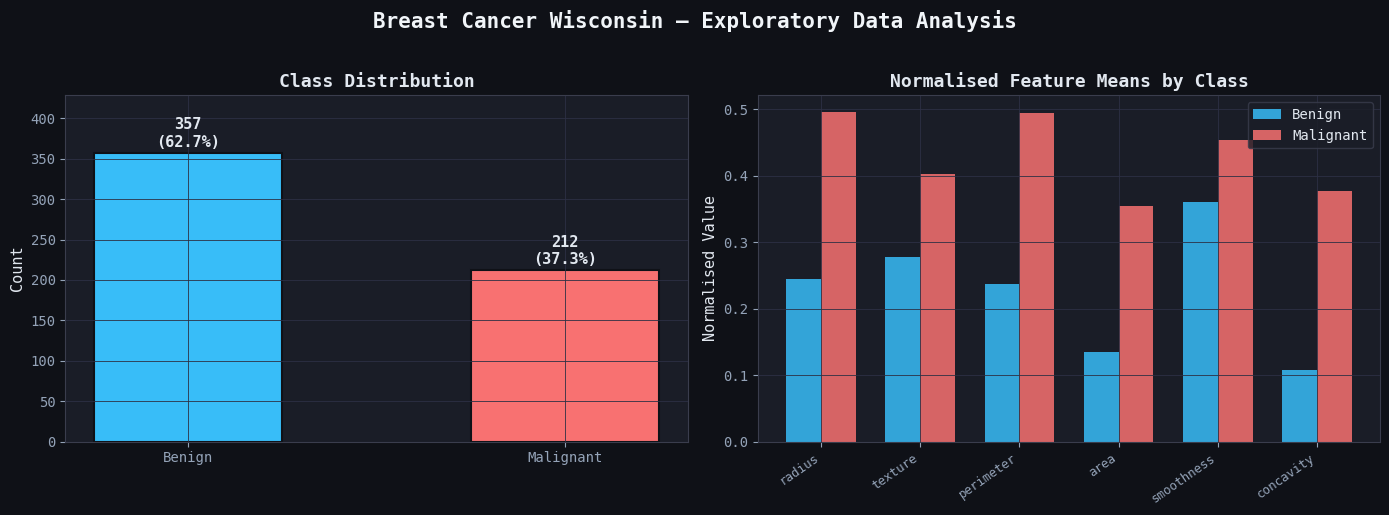


 Observation: Malignant tumors consistently show higher values across ALL geometric features.


In [ ]:
# EDA: class distribution + feature correlations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Breast Cancer Wisconsin — Exploratory Data Analysis',
             fontsize=15, fontweight='bold', color='#f1f5f9', y=1.02)

# Class distribution
ax = axes[0]
counts = df['diagnosis_label'].value_counts()
bars = ax.bar(counts.index, counts.values,
              color=[PALETTE[k] for k in counts.index],
              edgecolor='#0f1117', linewidth=1.5, width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
            f'{val}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom',
            fontsize=11, color='#e2e8f0', fontweight='bold')
ax.set_title('Class Distribution', fontweight='bold')
ax.set_ylabel('Count')
ax.set_ylim(0, max(counts.values) * 1.2)

# Feature box comparison (top 6 mean features)
ax = axes[1]
top_feats = ['mean radius', 'mean texture', 'mean perimeter',
             'mean area', 'mean smoothness', 'mean concavity']
# Normalize for comparison
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_norm = df.copy()
df_norm[top_feats] = scaler.fit_transform(df[top_feats])

benign_means    = df_norm[df_norm.diagnosis==1][top_feats].mean()
malignant_means = df_norm[df_norm.diagnosis==0][top_feats].mean()

x = np.arange(len(top_feats))
width = 0.35
ax.bar(x - width/2, benign_means,    width, label='Benign',    color=C_BEN, alpha=0.85)
ax.bar(x + width/2, malignant_means, width, label='Malignant', color=C_MAL, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f.replace('mean ','') for f in top_feats], rotation=35, ha='right', fontsize=9)
ax.set_title('Normalised Feature Means by Class', fontweight='bold')
ax.set_ylabel('Normalised Value')
ax.legend(facecolor='#1a1d27', edgecolor='#3a3d4d')

plt.tight_layout()
plt.show()
print('\n Observation: Malignant tumors consistently show higher values across ALL geometric features.')

---
## 🌲 Section 2: Decision Trees — How Do They Work?

A Decision Tree works by **recursively splitting** the dataset based on feature thresholds that best separate the classes.

### 🔢 Splitting Criterion: Gini Impurity

At each node, the algorithm asks: *"Which feature and threshold creates the purest child nodes?"*

$$\text{Gini}(t) = 1 - \sum_{k} p_k^2$$

Where $p_k$ is the fraction of samples belonging to class $k$ at node $t$.

- **Gini = 0** → perfectly pure node (all samples same class) ✅
- **Gini = 0.5** → maximum impurity (50/50 split) ⚠️

### 🔢 Alternative: Entropy (Information Gain)

$$H(t) = -\sum_{k} p_k \log_2(p_k)$$

Both work similarly in practice. Gini is faster (no log); Entropy tends to produce slightly more balanced trees.

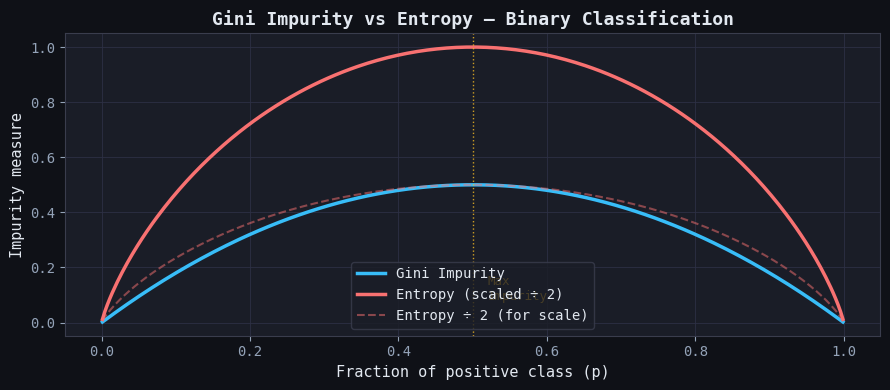

In [ ]:
# Visualise Gini vs Entropy
p = np.linspace(0.001, 0.999, 300)
gini    = 2 * p * (1 - p)           # binary Gini = 1 - p² - (1-p)²
entropy = -p * np.log2(p) - (1-p) * np.log2(1-p)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(p, gini,    color=C_BEN, lw=2.5, label='Gini Impurity')
ax.plot(p, entropy, color=C_MAL, lw=2.5, label='Entropy (scaled ÷ 2)')
ax.plot(p, entropy/2, color=C_MAL, lw=1.5, linestyle='--', alpha=0.5, label='Entropy ÷ 2 (for scale)')
ax.axvline(0.5, color='#fbbf24', lw=1, linestyle=':', alpha=0.8)
ax.text(0.52, 0.08, 'Max\nImpurity', color='#fbbf24', fontsize=9)
ax.set_xlabel('Fraction of positive class (p)')
ax.set_ylabel('Impurity measure')
ax.set_title('Gini Impurity vs Entropy — Binary Classification', fontweight='bold')
ax.legend(facecolor='#1a1d27', edgecolor='#3a3d4d')
plt.tight_layout()
plt.show()

---
## 🔬 Section 3: Train a Decision Tree

In [ ]:
# Train/test split
X = cancer.data
y = cancer.target
feature_names = cancer.feature_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')
print(f'Features         : {X_train.shape[1]}')

Training samples : 455
Test samples     : 114
Features         : 30


In [ ]:
# Train a shallow Decision Tree (max_depth=3)
dt_shallow = DecisionTreeClassifier(max_depth=3, random_state=42, criterion='gini')
dt_shallow.fit(X_train, y_train)

train_acc = dt_shallow.score(X_train, y_train)
test_acc  = dt_shallow.score(X_test,  y_test)
print(f'Shallow Tree (depth=3)  →  Train: {train_acc:.4f}  |  Test: {test_acc:.4f}')

Shallow Tree (depth=3)  →  Train: 0.9758  |  Test: 0.9386


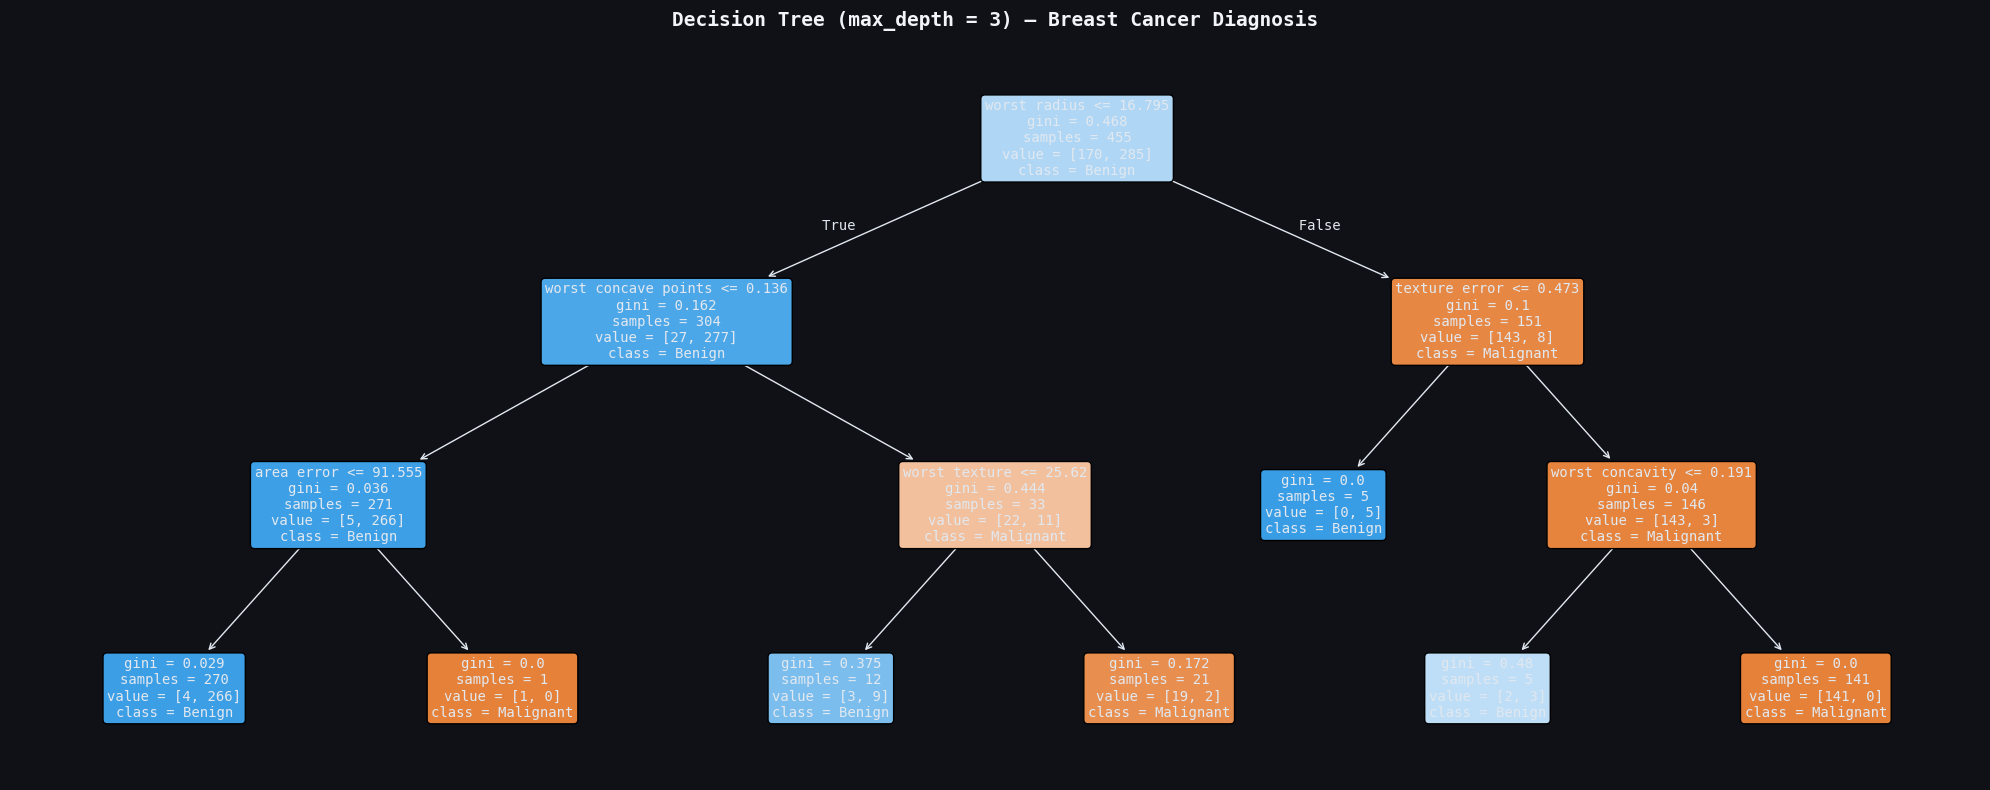


📖 How to read this tree:
  • Each internal node shows: split condition | Gini | samples | class distribution
  • Leaf nodes show the predicted class
  • Orange nodes → lean Malignant | Blue nodes → lean Benign


In [ ]:
# Visualise the shallow tree
fig, ax = plt.subplots(figsize=(20, 8), facecolor='#0f1117')
ax.set_facecolor('#0f1117')

plot_tree(
    dt_shallow,
    feature_names=feature_names,
    class_names=['Malignant', 'Benign'],
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax,
    impurity=True,
    proportion=False
)

ax.set_title('Decision Tree (max_depth = 3) — Breast Cancer Diagnosis',
             fontsize=14, fontweight='bold', color='#f1f5f9', pad=15)
plt.tight_layout()
plt.show()

print('\n📖 How to read this tree:')
print('  • Each internal node shows: split condition | Gini | samples | class distribution')
print('  • Leaf nodes show the predicted class')
print('  • Orange nodes → lean Malignant | Blue nodes → lean Benign')

In [ ]:
# Print tree as text rules
rules = export_text(dt_shallow, feature_names=list(feature_names))
print('📜 Decision Rules (text format):')
print('─' * 60)
print(rules)

📜 Decision Rules (text format):
────────────────────────────────────────────────────────────
|--- worst radius <= 16.80
|   |--- worst concave points <= 0.14
|   |   |--- area error <= 91.56
|   |   |   |--- class: 1
|   |   |--- area error >  91.56
|   |   |   |--- class: 0
|   |--- worst concave points >  0.14
|   |   |--- worst texture <= 25.62
|   |   |   |--- class: 1
|   |   |--- worst texture >  25.62
|   |   |   |--- class: 0
|--- worst radius >  16.80
|   |--- texture error <= 0.47
|   |   |--- class: 1
|   |--- texture error >  0.47
|   |   |--- worst concavity <= 0.19
|   |   |   |--- class: 1
|   |   |--- worst concavity >  0.19
|   |   |   |--- class: 0



---
## ⚠️ Section 4: The Overfitting Problem

Decision Trees are **prone to overfitting** — they can memorize training data perfectly (Gini = 0 at every leaf) but fail on new data.

Let's visualize this by training trees at increasing depths and comparing train vs test accuracy.

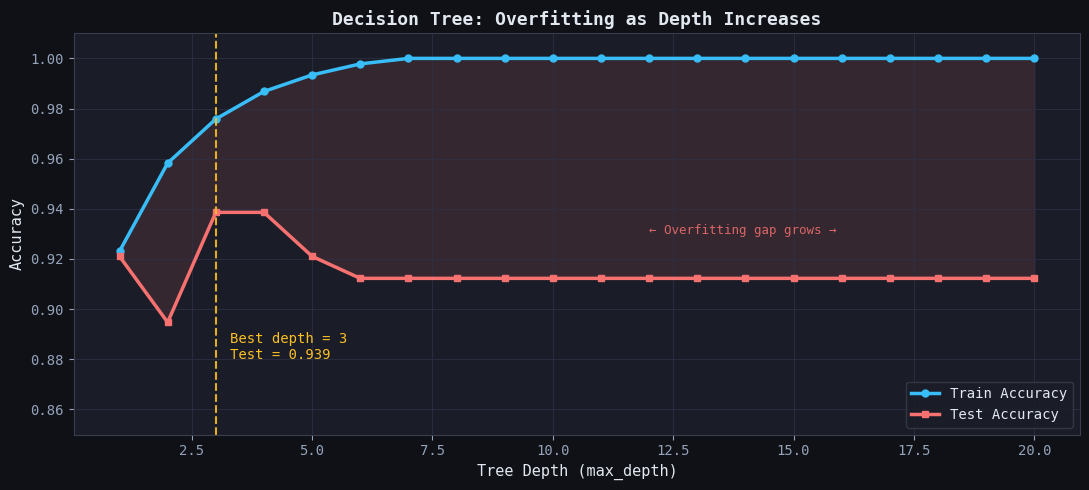


🔑 Key insight:
  • Training accuracy reaches 100% at depth ≥ 8 (memorization!)
  • Test accuracy peaks at depth 3 then DEGRADES
  • This gap = overfitting. We need a smarter approach → Random Forests


In [ ]:
# Overfitting curve: tree depth vs accuracy
depths = list(range(1, 21))
train_scores, test_scores = [], []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    train_scores.append(dt.score(X_train, y_train))
    test_scores.append(dt.score(X_test, y_test))

# Find sweet spot
best_depth = depths[np.argmax(test_scores)]
best_test  = max(test_scores)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(depths, train_scores, color=C_BEN, lw=2.5, marker='o', markersize=5, label='Train Accuracy')
ax.plot(depths, test_scores,  color=C_MAL, lw=2.5, marker='s', markersize=5, label='Test Accuracy')
ax.axvline(best_depth, color='#fbbf24', lw=1.5, linestyle='--', alpha=0.9)
ax.text(best_depth + 0.3, 0.88, f'Best depth = {best_depth}\nTest = {best_test:.3f}',
        color='#fbbf24', fontsize=10)

ax.fill_between(depths, train_scores, test_scores, alpha=0.12, color='#f87171')
ax.annotate('← Overfitting gap grows →', xy=(12, 0.93), fontsize=9, color='#f87171', alpha=0.85)

ax.set_xlabel('Tree Depth (max_depth)')
ax.set_ylabel('Accuracy')
ax.set_title('Decision Tree: Overfitting as Depth Increases', fontweight='bold')
ax.legend(facecolor='#1a1d27', edgecolor='#3a3d4d')
ax.set_ylim(0.85, 1.01)
plt.tight_layout()
plt.show()

print(f'\n🔑 Key insight:')
print(f'  • Training accuracy reaches 100% at depth ≥ 8 (memorization!)')
print(f'  • Test accuracy peaks at depth {best_depth} then DEGRADES')
print(f'  • This gap = overfitting. We need a smarter approach → Random Forests')

---
## 🌲🌲🌲 Section 5: Random Forests — The Ensemble Fix

Random Forests fix overfitting through two key ideas:

### 1. Bootstrap Aggregating (Bagging)
Each tree is trained on a **random sample with replacement** (bootstrap sample) of the training data. Different trees see different data → diversity!

### 2. Random Feature Subsets
At each split, only a **random subset of features** (typically $\sqrt{p}$) is considered. This further decorrelates the trees.

### Final Prediction = Majority Vote
$$\hat{y} = \text{mode}(T_1(x),\ T_2(x),\ \ldots,\ T_n(x))$$

> 🎯 **Intuition**: Even if individual trees overfit in different ways, their *average* mistakes cancel out. It's the wisdom of crowds applied to machine learning.

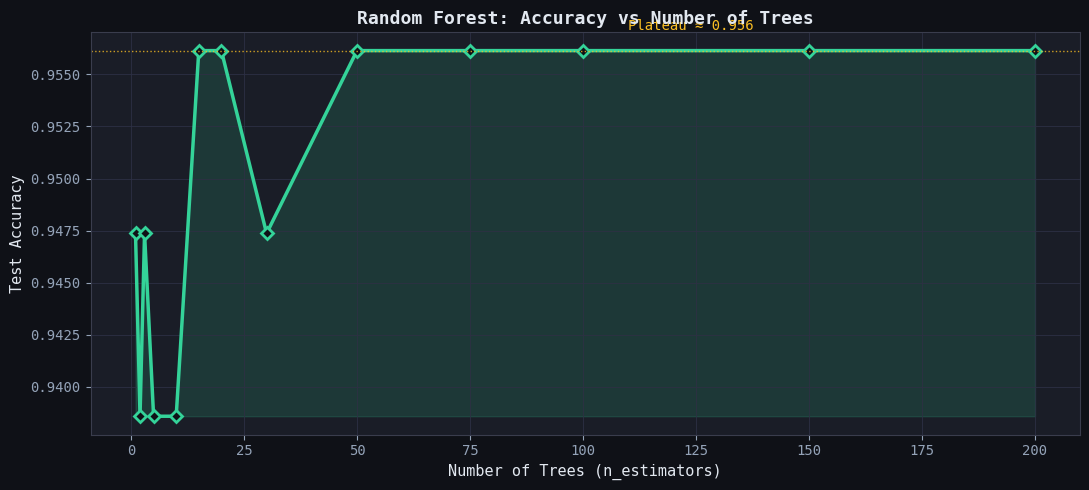


🔑 Insight: Accuracy improves quickly with few trees, then plateaus.
   Beyond ~50-100 trees, diminishing returns. Computational cost grows linearly.


In [ ]:
# Visual: how RF accuracy grows with number of trees
n_tree_range = [1, 2, 3, 5, 10, 15, 20, 30, 50, 75, 100, 150, 200]
rf_test_scores = []

for n in n_tree_range:
    rf = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    rf_test_scores.append(rf.score(X_test, y_test))

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(n_tree_range, rf_test_scores, color=C_ACC, lw=2.5, marker='D',
        markersize=6, markerfacecolor='#0f1117', markeredgewidth=2)
ax.axhline(max(rf_test_scores), color='#fbbf24', lw=1, linestyle=':', alpha=0.8)
ax.fill_between(n_tree_range, [min(rf_test_scores)]*len(n_tree_range),
                rf_test_scores, alpha=0.15, color=C_ACC)
ax.text(110, max(rf_test_scores)+0.001, f'Plateau ≈ {max(rf_test_scores):.3f}',
        color='#fbbf24', fontsize=10)

ax.set_xlabel('Number of Trees (n_estimators)')
ax.set_ylabel('Test Accuracy')
ax.set_title('Random Forest: Accuracy vs Number of Trees', fontweight='bold')
plt.tight_layout()
plt.show()

print('\n🔑 Insight: Accuracy improves quickly with few trees, then plateaus.')
print('   Beyond ~50-100 trees, diminishing returns. Computational cost grows linearly.')

---
## 🏆 Section 6: Final Models — Train & Evaluate

In [ ]:
# Train final models

# Decision Tree with best depth
dt_final = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt_final.fit(X_train, y_train)

# Random Forest — 100 trees
rf_final = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_final.fit(X_train, y_train)

# Predictions
dt_pred  = dt_final.predict(X_test)
rf_pred  = rf_final.predict(X_test)
dt_proba = dt_final.predict_proba(X_test)[:, 1]
rf_proba = rf_final.predict_proba(X_test)[:, 1]

print('── Decision Tree ────────────────────────────────────────')
print(classification_report(y_test, dt_pred, target_names=['Malignant', 'Benign']))
print('── Random Forest ────────────────────────────────────────')
print(classification_report(y_test, rf_pred, target_names=['Malignant', 'Benign']))

── Decision Tree ────────────────────────────────────────
              precision    recall  f1-score   support

   Malignant       0.93      0.90      0.92        42
      Benign       0.95      0.96      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114

── Random Forest ────────────────────────────────────────
              precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        42
      Benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



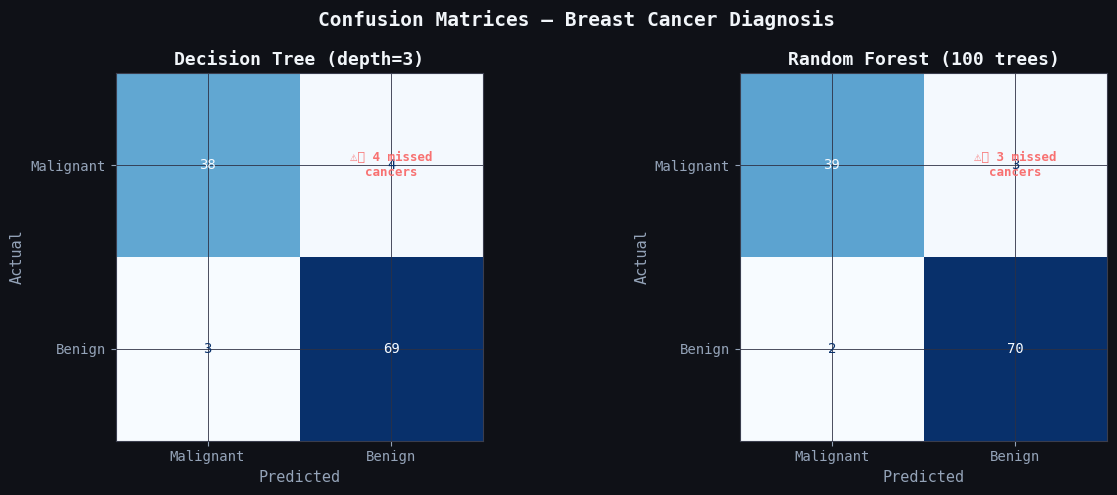


⚠️  False Negatives (missed cancers):
   Decision Tree : 4
   Random Forest : 3

   In medical context, every missed cancer is critical!


In [ ]:
# Side-by-side confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Confusion Matrices — Breast Cancer Diagnosis',
             fontsize=14, fontweight='bold', color='#f1f5f9')

for ax, pred, title in zip(axes, [dt_pred, rf_pred],
                            [f'Decision Tree (depth={best_depth})', 'Random Forest (100 trees)']):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Malignant', 'Benign'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title, fontweight='bold', color='#f1f5f9')
    ax.set_xlabel('Predicted', color='#94a3b8')
    ax.set_ylabel('Actual', color='#94a3b8')

    # Annotate false negatives (clinically critical)
    fn = cm[0, 1]  # Malignant predicted as Benign
    ax.text(1, 0, f'⚠️ {fn} missed\ncancers', ha='center', va='center',
            fontsize=9, color='#f87171', fontweight='bold')

plt.tight_layout()
plt.show()

dt_fn = confusion_matrix(y_test, dt_pred)[0,1]
rf_fn = confusion_matrix(y_test, rf_pred)[0,1]
print(f'\n⚠️  False Negatives (missed cancers):')
print(f'   Decision Tree : {dt_fn}')
print(f'   Random Forest : {rf_fn}')
print(f'\n   In medical context, every missed cancer is critical!')

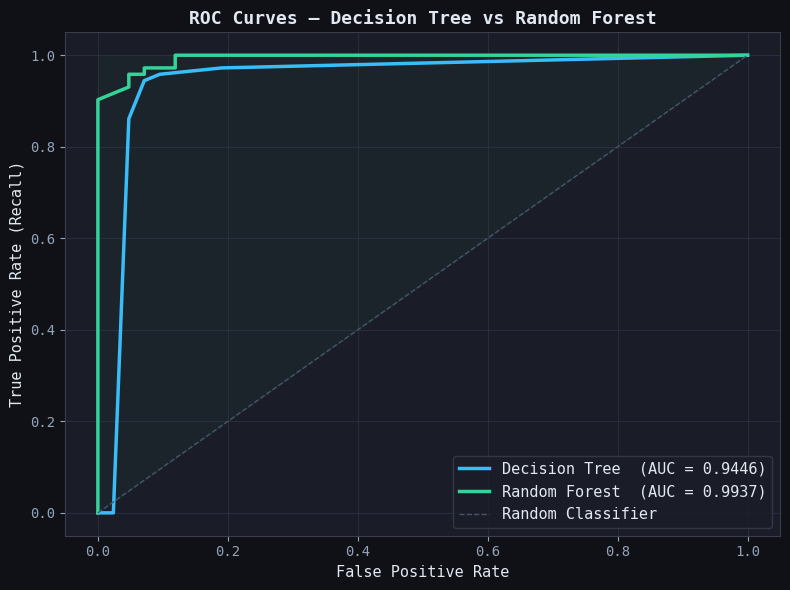

In [ ]:
# ROC Curves
fig, ax = plt.subplots(figsize=(8, 6))

for name, proba, color in [
    ('Decision Tree', dt_proba, C_BEN),
    ('Random Forest', rf_proba, C_ACC)
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, color=color, lw=2.5, label=f'{name}  (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], color='#475569', lw=1, linestyle='--', label='Random Classifier')
ax.fill_between([0,1],[0,1],[1,1], alpha=0.04, color=C_ACC)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curves — Decision Tree vs Random Forest', fontweight='bold')
ax.legend(facecolor='#1a1d27', edgecolor='#3a3d4d', fontsize=11)
plt.tight_layout()
plt.show()

---
## 🔍 Section 7: Feature Importance

Random Forests provide **built-in feature importance** scores — which features contributed most to reducing impurity across all trees?

This is one of the most useful outputs for understanding a model and doing feature selection.

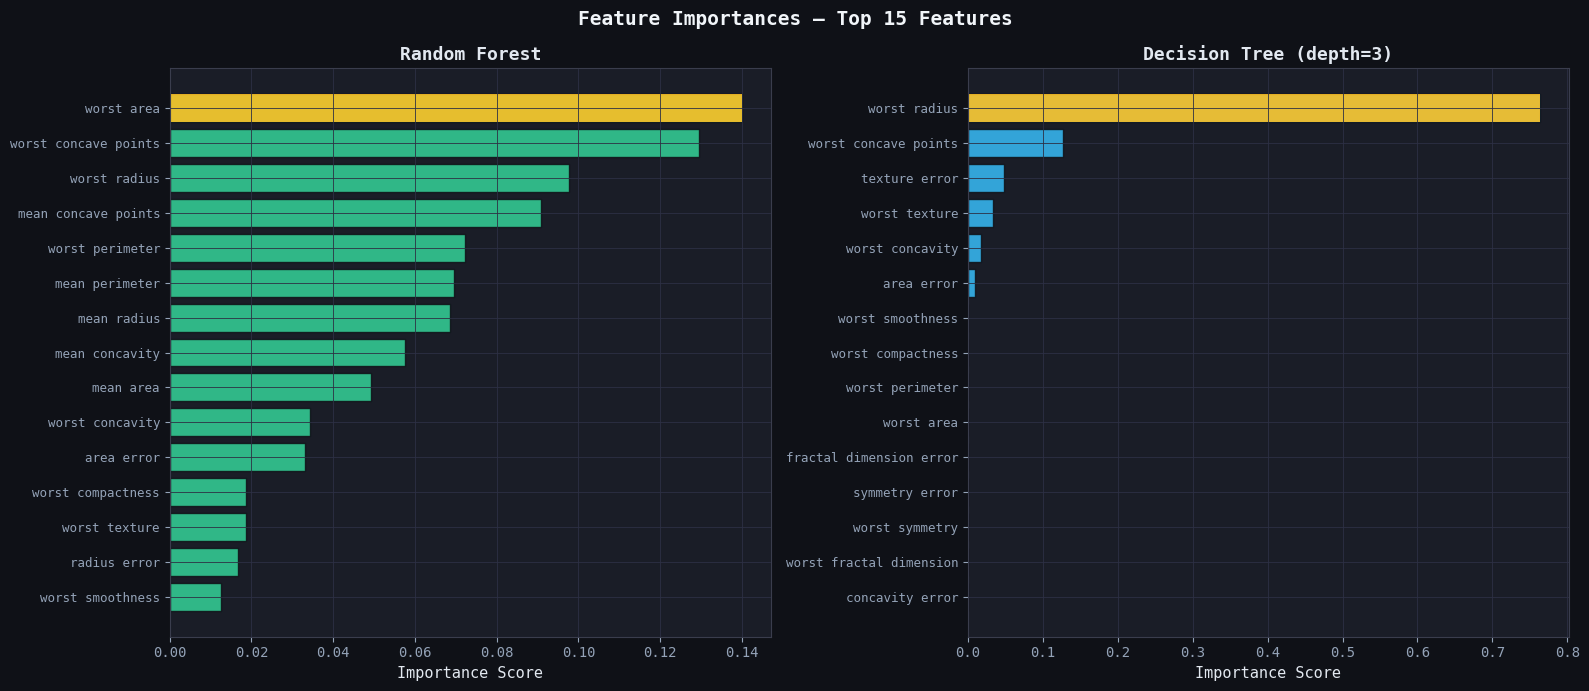


🏅 Top 3 features (Random Forest): ['worst area', 'worst concave points', 'worst radius']

🔑 Note: RF spreads importance across many features (robust).
         Single DT concentrates on 1-2 features (brittle).


In [ ]:
# Feature Importance: RF vs single DT
rf_importance = pd.Series(rf_final.feature_importances_, index=feature_names).sort_values(ascending=True)
dt_importance = pd.Series(dt_final.feature_importances_, index=feature_names).sort_values(ascending=True)

top_n = 15
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Feature Importances — Top 15 Features', fontsize=14, fontweight='bold', color='#f1f5f9')

for ax, imp, title, color in zip(
    axes,
    [rf_importance.tail(top_n), dt_importance.tail(top_n)],
    ['Random Forest', f'Decision Tree (depth={best_depth})'],
    [C_ACC, C_BEN]
):
    bars = ax.barh(range(len(imp)), imp.values, color=color, alpha=0.85, edgecolor='#0f1117')
    ax.set_yticks(range(len(imp)))
    ax.set_yticklabels(imp.index, fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Importance Score')

    # Annotate top feature
    top_val = imp.values[-1]
    ax.barh(len(imp)-1, top_val, color='#fbbf24', alpha=0.9)

plt.tight_layout()
plt.show()

top3_rf = rf_importance.tail(3).index.tolist()[::-1]
print(f'\n🏅 Top 3 features (Random Forest): {top3_rf}')
print('\n🔑 Note: RF spreads importance across many features (robust).')
print('         Single DT concentrates on 1-2 features (brittle).')

---
## ⚙️ Section 8: Hyperparameter Tuning with GridSearchCV

In [ ]:
# GridSearchCV for Decision Tree
dt_param_grid = {
    'max_depth':        [2, 3, 4, 5, 6, 7, 8],
    'min_samples_split': [2, 5, 10, 20],
    'criterion':        ['gini', 'entropy']
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_param_grid,
    cv=5,
    scoring='f1',      # Use F1 for medical tasks (balance precision & recall)
    n_jobs=-1
)
dt_grid.fit(X_train, y_train)

print('── Best Decision Tree Params ──────────────────────────────')
print(dt_grid.best_params_)
print(f'Best CV F1 score : {dt_grid.best_score_:.4f}')
print(f'Test Accuracy    : {dt_grid.best_estimator_.score(X_test, y_test):.4f}')

── Best Decision Tree Params ──────────────────────────────
{'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 5}
Best CV F1 score : 0.9518
Test Accuracy    : 0.9211


In [ ]:
# GridSearchCV for Random Forest
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth':    [None, 5, 10, 15],
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)

print('── Best Random Forest Params ──────────────────────────────')
print(rf_grid.best_params_)
print(f'Best CV F1 score : {rf_grid.best_score_:.4f}')
print(f'Test Accuracy    : {rf_grid.best_estimator_.score(X_test, y_test):.4f}')

── Best Random Forest Params ──────────────────────────────
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
Best CV F1 score : 0.9684
Test Accuracy    : 0.9561


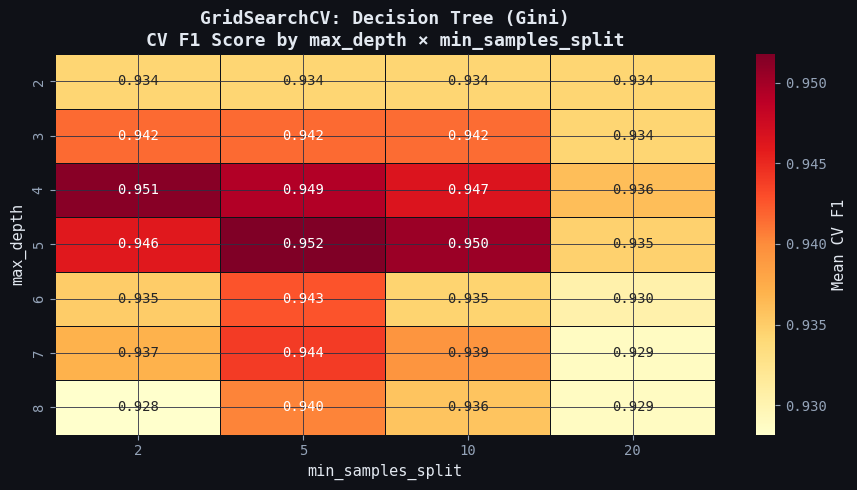

In [ ]:
# Heatmap: GridSearch results for DT
results = pd.DataFrame(dt_grid.cv_results_)
# Filter to gini only for clean visual
gini_results = results[results['param_criterion'] == 'gini'].copy()

pivot = gini_results.pivot_table(
    index='param_max_depth',
    columns='param_min_samples_split',
    values='mean_test_score'
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd',
            ax=ax, cbar_kws={'label': 'Mean CV F1'},
            linewidths=0.5, linecolor='#0f1117')
ax.set_title('GridSearchCV: Decision Tree (Gini)\nCV F1 Score by max_depth × min_samples_split',
             fontweight='bold')
ax.set_xlabel('min_samples_split')
ax.set_ylabel('max_depth')
plt.tight_layout()
plt.show()

---
## 📊 Section 9: Cross-Validation — Robust Performance Estimates

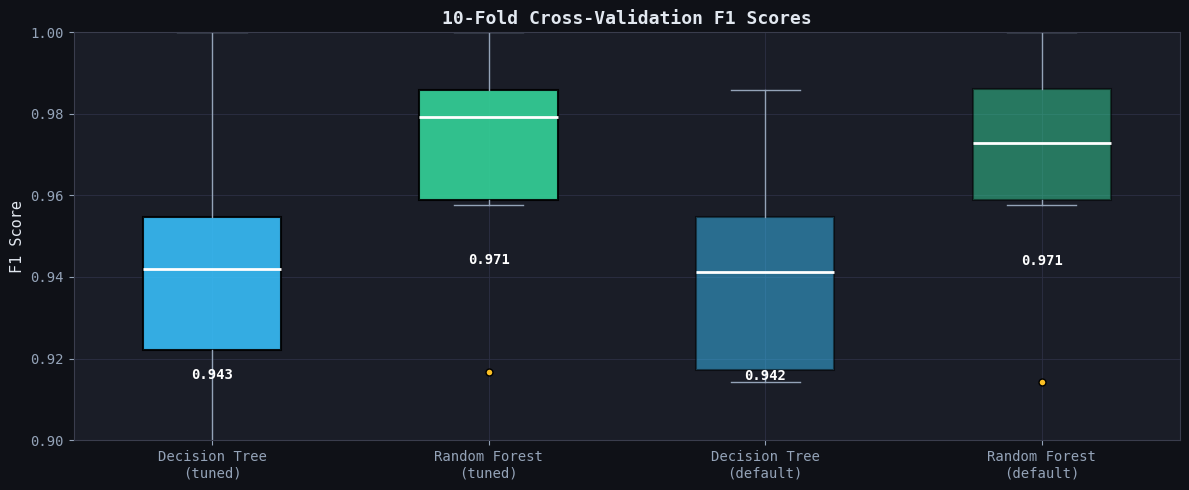


📋 Summary:
  Decision Tree (tuned)           Mean F1=0.9426  ±0.0316
  Random Forest (tuned)           Mean F1=0.9708  ±0.0227
  Decision Tree (default)         Mean F1=0.9424  ±0.0258
  Random Forest (default)         Mean F1=0.9708  ±0.0248


In [ ]:
# 10-fold cross validation comparison
models = {
    'Decision Tree\n(tuned)': dt_grid.best_estimator_,
    'Random Forest\n(tuned)': rf_grid.best_estimator_,
    'Decision Tree\n(default)': DecisionTreeClassifier(random_state=42),
    'Random Forest\n(default)': RandomForestClassifier(random_state=42)
}

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=10, scoring='f1', n_jobs=-1)
    cv_results[name] = scores

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
colors = [C_BEN, C_ACC, C_BEN, C_ACC]
alphas = [0.9, 0.9, 0.5, 0.5]

positions = np.arange(len(cv_results))
for i, (name, scores) in enumerate(cv_results.items()):
    bp = ax.boxplot(scores, positions=[i], widths=0.5,
                    patch_artist=True,
                    boxprops=dict(facecolor=colors[i], alpha=alphas[i], linewidth=1.5),
                    medianprops=dict(color='white', linewidth=2),
                    whiskerprops=dict(color='#94a3b8'),
                    capprops=dict(color='#94a3b8'),
                    flierprops=dict(marker='o', markerfacecolor='#fbbf24', markersize=5))
    ax.text(i, np.mean(scores) - 0.025, f'{np.mean(scores):.3f}',
            ha='center', va='top', fontsize=10, fontweight='bold', color='white')

ax.set_xticks(positions)
ax.set_xticklabels(cv_results.keys(), fontsize=10)
ax.set_ylabel('F1 Score')
ax.set_title('10-Fold Cross-Validation F1 Scores', fontweight='bold')
ax.set_ylim(0.9, 1.0)
plt.tight_layout()
plt.show()

print('\n📋 Summary:')
for name, scores in cv_results.items():
    print(f'  {name.replace(chr(10), " "):30s}  Mean F1={np.mean(scores):.4f}  ±{np.std(scores):.4f}')

---
## 🎯 Section 10: Final Comparison Dashboard

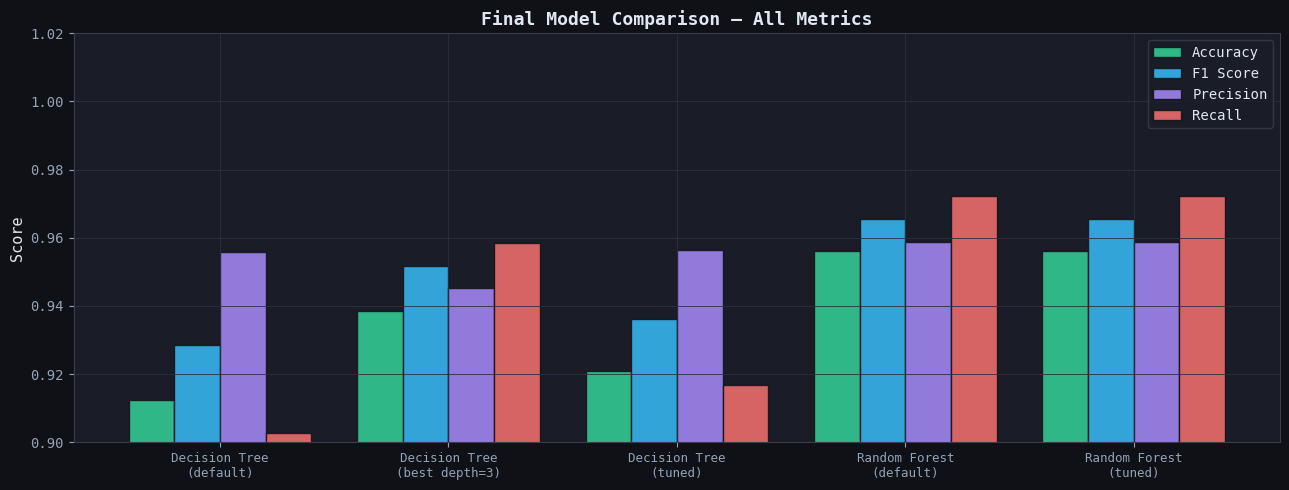

                               Accuracy  F1 Score  Precision  Recall
Decision Tree\n(default)         0.9123    0.9286     0.9559  0.9028
Decision Tree\n(best depth=3)    0.9386    0.9517     0.9452  0.9583
Decision Tree\n(tuned)           0.9211    0.9362     0.9565  0.9167
Random Forest\n(default)         0.9561    0.9655     0.9589  0.9722
Random Forest\n(tuned)           0.9561    0.9655     0.9589  0.9722


In [ ]:
# Final comparison summary
from sklearn.metrics import f1_score, precision_score, recall_score

comparison_data = {}
for name, model in [
    ('Decision Tree\n(default)', DecisionTreeClassifier(random_state=42)),
    (f'Decision Tree\n(best depth={best_depth})', dt_final),
    ('Decision Tree\n(tuned)', dt_grid.best_estimator_),
    ('Random Forest\n(default)', RandomForestClassifier(random_state=42)),
    ('Random Forest\n(tuned)', rf_grid.best_estimator_),
]:
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    comparison_data[name] = {
        'Accuracy':  accuracy_score(y_test, pred),
        'F1 Score':  f1_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall':    recall_score(y_test, pred),
    }

comp_df = pd.DataFrame(comparison_data).T

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(comp_df))
width = 0.2
metric_colors = [C_ACC, C_BEN, '#a78bfa', C_MAL]

for i, (metric, color) in enumerate(zip(comp_df.columns, metric_colors)):
    bars = ax.bar(x + i*width, comp_df[metric], width,
                  label=metric, color=color, alpha=0.85, edgecolor='#0f1117')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(comp_df.index, fontsize=9)
ax.set_ylim(0.9, 1.02)
ax.set_ylabel('Score')
ax.set_title('Final Model Comparison — All Metrics', fontweight='bold')
ax.legend(facecolor='#1a1d27', edgecolor='#3a3d4d', fontsize=10)
plt.tight_layout()
plt.show()

print(comp_df.to_string(float_format='{:.4f}'.format))

---
## 📖 Section 11: Key Takeaways & Cheat Sheet

### ✅ Decision Trees
| Property | Detail |
|---|---|
| **Interpretability** | High — can be visualized as rules |
| **Overfitting** | Very prone without depth control |
| **Speed** | Very fast to train & predict |
| **Key hyperparams** | `max_depth`, `min_samples_split`, `criterion` |
| **Best for** | Quick baselines, rule extraction, small datasets |

### ✅ Random Forests
| Property | Detail |
|---|---|
| **Interpretability** | Low (ensemble of many trees) |
| **Overfitting** | Resistant due to bagging + feature randomness |
| **Speed** | Slower (but parallelizable) |
| **Key hyperparams** | `n_estimators`, `max_depth`, `max_features`, `min_samples_split` |
| **Best for** | General purpose, tabular data, when accuracy matters most |

### 🔑 Rules of Thumb
1. **Start with Random Forest** — it almost always beats a single tree
2. **Use `max_depth=3–5`** for interpretable decision trees
3. **100 trees** is usually enough for Random Forest; more rarely helps
4. **`max_features='sqrt'`** is the default — works well for classification
5. **Use F1 score** (not just accuracy) when classes are imbalanced
6. **Cross-validate** — a single train/test split can be misleading

### 🚀 Next Steps
- Try **Gradient Boosting** (XGBoost, LightGBM) — often beats RF
- Explore **SHAP values** for deeper feature importance analysis
- Apply these models to your own tabular dataset!

In [ ]:
# Quick Reference: Complete RF pipeline in 10 lines
print('=' * 55)
print('  RANDOM FOREST — COMPLETE PIPELINE (10 LINES)')
print('=' * 55)
print('''
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print(classification_report(y_test, rf.predict(X_test)))
print(rf.feature_importances_)   # Feature importance
''')

print('🎉 Notebook complete! You now understand Decision Trees & Random Forests.')

  RANDOM FOREST — COMPLETE PIPELINE (10 LINES)

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print(classification_report(y_test, rf.predict(X_test)))
print(rf.feature_importances_)   # Feature importance

🎉 Notebook complete! You now understand Decision Trees & Random Forests.
